# Description

In this notebook, we apply CEQL method to approximate the frequency response function of a beam.

In [1]:
from __future__ import annotations

import re
from pathlib import Path
from typing import List, Tuple, Dict

import numpy as np
import sympy as sp
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from config.frf_config import CEQL_TRAIN, CEQL
from src.ComplexEQL import ComplexEQL
from src.utils import set_seed, train
from src.sympy_utils import filter_imaginary_part


# ============================================================
# GLOBALS (EDIT HERE)
# ============================================================

# Full list of available feature tokens (use any subset; order matters):
#   "f"          -> frequency [Hz]
#   "sin_phase"  -> sin(phase_rad)
#   "cos_phase"  -> cos(phase_rad)
#   "z1"         -> z1 = (mass1_present)*NOMINAL_MASS*L1
#   "z2"         -> z2 = (mass2_present)*NOMINAL_MASS*L2
#   "z3"         -> z3 = (mass3_present)*NOMINAL_MASS*L3
#   "z4"         -> z4 = (mass4_present)*NOMINAL_MASS*L4
#   "z5"         -> z5 = (mass5_present)*NOMINAL_MASS*L5
#   "z6"         -> z6 = (mass6_present)*NOMINAL_MASS*L6
#
# Examples:
# FEATURE_TOKENS = ["f"]
# FEATURE_TOKENS = ["f", "sin_phase", "cos_phase"]
# FEATURE_TOKENS = ["f", "z1", "z2", "z3", "z4", "z5", "z6"]
# FEATURE_TOKENS = ["f", "sin_phase", "cos_phase", "z1", "z2", "z3", "z4", "z5", "z6"]
FEATURE_TOKENS: List[str] = ["f", "sin_phase", "cos_phase", "z1", "z2", "z3", "z4", "z5", "z6"]

# Split settings (split is per trajectory/experiment/file)
SEED = 42
TEST_RATIO = 0.2

# Subsample TRAIN by number of POINTS (after building all train trajectories)
# If None: keep all train points
N_TRAIN_POINTS: int | None = 10000

# Magnet mass scale (only affects z-features scale)
NOMINAL_MASS = 1.0

# Data paths (script is one level above frf_data/)
try:
    ROOT = Path(__file__).resolve().parent
except NameError:
    ROOT = Path.cwd()

DATA = ROOT / "frf_data"

FRF_FOLDERS = {
    "healthy": DATA / "1-Beam_healthy",
    "damage_2.96": DATA / "2-Beam_damage_2.96",
    "damage_5.92": DATA / "3-Beam_damage_5.92",
    "damage_8.87": DATA / "4-Beam_damage_8.87",
}

MASS_POS_XLSX = DATA / "Mass position.xlsx"
MASS_POS_SHEET = "Posições aleatórias"

# Keep config consistent with selected features
CEQL.n_input_fields = len(FEATURE_TOKENS)


# ============================================================
# Robust FRF TXT reader
# ============================================================
_NUM = re.compile(r"[-+]?(?:\d+(?:\.\d*)?|\.\d+)(?:[eE][-+]?\d+)?")

def read_frf_txt(path: Path) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    text = path.read_bytes().decode("latin-1", errors="ignore")
    f_list, m_list, p_list = [], [], []
    for line in text.splitlines():
        line = line.strip()
        if not line:
            continue
        nums = _NUM.findall(line)
        if len(nums) < 3:
            continue
        f = float(nums[0]); mag = float(nums[1]); ph = float(nums[2])
        if not (np.isfinite(f) and np.isfinite(mag) and np.isfinite(ph)):
            continue
        f_list.append(f); m_list.append(mag); p_list.append(ph)
    if not f_list:
        raise ValueError(f"No numeric data parsed from {path}")
    f = np.asarray(f_list, dtype=float)
    mag = np.asarray(m_list, dtype=float)
    ph = np.asarray(p_list, dtype=float)
    idx = np.argsort(f)
    return f[idx], mag[idx], ph[idx]


# ============================================================
# Parse filenames: P-<sample>.txt, P-<sample>-<suffix>.txt
# ============================================================
_RE_FILE = re.compile(r"^P-(\d+)(?:-(\d+))?$")

def parse_file_id(fp: Path) -> tuple[int, int]:
    m = _RE_FILE.match(fp.stem)
    if not m:
        raise ValueError(f"Unexpected FRF filename: {fp.name}")
    sample = int(m.group(1))
    suffix = int(m.group(2)) if m.group(2) is not None else 0
    return sample, suffix


# ============================================================
# Read mass positions: sample -> L1..L6
# ============================================================
def load_mass_positions(xlsx_path: Path, sheet_name: str) -> np.ndarray:
    import pandas as pd

    df0 = pd.read_excel(xlsx_path, sheet_name=sheet_name)

    cols_pos = [
        "Masses position values [mm]",
        "Unnamed: 2",
        "Unnamed: 3",
        "Unnamed: 4",
        "Unnamed: 5",
        "Unnamed: 6",
    ]
    names = [str(df0.loc[0, c]).strip() for c in cols_pos]

    df = df0.loc[1:, ["Samples"] + cols_pos].copy()
    df = df.rename(columns={"Samples": "sample", **{c: n for c, n in zip(cols_pos, names)}})

    df["sample"] = pd.to_numeric(df["sample"], errors="coerce").astype("Int64")
    for n in names:
        df[n] = pd.to_numeric(df[n], errors="coerce")

    df = df.dropna(subset=["sample"]).astype({"sample": int})
    df = df[["sample"] + names].reset_index(drop=True)

    max_sample = int(df["sample"].max())
    pos = np.full((max_sample + 1, 6), np.nan, dtype=float)
    for _, r in df.iterrows():
        s = int(r["sample"])
        pos[s, :] = [float(r[n]) for n in names]
    return pos


POS_BY_SAMPLE = load_mass_positions(MASS_POS_XLSX, MASS_POS_SHEET)


# ============================================================
# Presence masks per condition (L1,L3,L5 removed progressively)
# ============================================================
def present_mask(cond: str) -> np.ndarray:
    mask = np.ones(6, dtype=float)
    if cond == "damage_2.96":
        mask[0] = 0.0
    elif cond == "damage_5.92":
        mask[0] = 0.0
        mask[2] = 0.0
    elif cond == "damage_8.87":
        mask[0] = 0.0
        mask[2] = 0.0
        mask[4] = 0.0
    return mask


# ============================================================
# Feature construction
# ============================================================
def build_feature_matrix(
    *,
    f: np.ndarray,
    mag_db: np.ndarray,
    ph_deg: np.ndarray,
    cond: str,
    sample: int,
    feature_tokens: List[str],
) -> tuple[np.ndarray, np.ndarray]:
    phi = np.deg2rad(ph_deg)
    sinp = np.sin(phi)
    cosp = np.cos(phi)

    pos = POS_BY_SAMPLE[sample, :].astype(float)
    if not np.isfinite(pos).all():
        raise ValueError(f"Missing positions for sample={sample} from {MASS_POS_XLSX}")

    m = NOMINAL_MASS * present_mask(cond)
    z = (m * pos).astype(float)

    feature_bank: Dict[str, np.ndarray] = {
        "f": f.astype(np.float32),
        "sin_phase": sinp.astype(np.float32),
        "cos_phase": cosp.astype(np.float32),
        "z1": np.full_like(f, z[0], dtype=np.float32),
        "z2": np.full_like(f, z[1], dtype=np.float32),
        "z3": np.full_like(f, z[2], dtype=np.float32),
        "z4": np.full_like(f, z[3], dtype=np.float32),
        "z5": np.full_like(f, z[4], dtype=np.float32),
        "z6": np.full_like(f, z[5], dtype=np.float32),
    }

    missing = [t for t in feature_tokens if t not in feature_bank]
    if missing:
        raise ValueError(f"Unknown feature tokens: {missing}. Available: {sorted(feature_bank.keys())}")

    X = np.concatenate([feature_bank[t].reshape(-1, 1) for t in feature_tokens], axis=1).astype(np.float32)
    y = mag_db.astype(np.float32).reshape(-1, 1)
    return X, y


def feature_symbols(feature_tokens: List[str]) -> List[sp.Symbol]:
    name_map = {
        "f": "f",
        "sin_phase": "sphi",
        "cos_phase": "cphi",
        "z1": "z1",
        "z2": "z2",
        "z3": "z3",
        "z4": "z4",
        "z5": "z5",
        "z6": "z6",
    }
    return [sp.Symbol(name_map[t]) for t in feature_tokens]


# ============================================================
# Build experiment list + split by experiment
# ============================================================
experiments: List[Tuple[str, str, int, Path]] = []
for cond, folder in FRF_FOLDERS.items():
    for fp in sorted(folder.glob("*.txt")):
        sample, _suffix = parse_file_id(fp)
        exp_id = f"{cond}/{fp.name}"
        experiments.append((exp_id, cond, sample, fp))

rng = np.random.RandomState(SEED)
rng.shuffle(experiments)

n_test = int(round(TEST_RATIO * len(experiments)))
test_exp_ids = set(e[0] for e in experiments[:n_test])
train_exp_ids = set(e[0] for e in experiments[n_test:])


# ============================================================
# Materialize train/test point datasets (ALL trajectories)
# ============================================================
X_train_list, y_train_list = [], []
X_test_list, y_test_list = [], []

for exp_id, cond, sample, fp in experiments:
    f, mag_db, ph_deg = read_frf_txt(fp)
    X, y = build_feature_matrix(
        f=f,
        mag_db=mag_db,
        ph_deg=ph_deg,
        cond=cond,
        sample=sample,
        feature_tokens=FEATURE_TOKENS,
    )

    if exp_id in test_exp_ids:
        X_test_list.append(X); y_test_list.append(y)
    else:
        X_train_list.append(X); y_train_list.append(y)

X_train = np.concatenate(X_train_list, axis=0)
y_train = np.concatenate(y_train_list, axis=0)
X_test = np.concatenate(X_test_list, axis=0)
y_test = np.concatenate(y_test_list, axis=0)

# ============================================================
# Subsample TRAIN by NUMBER OF POINTS (random over all train points)
# ============================================================
if N_TRAIN_POINTS is not None:
    rng = np.random.RandomState(SEED)
    if X_train.shape[0] > N_TRAIN_POINTS:
        idx = rng.choice(X_train.shape[0], size=N_TRAIN_POINTS, replace=False)
        X_train = X_train[idx]
        y_train = y_train[idx]

print("Selected features:", FEATURE_TOKENS)
print("Train points:", X_train.shape, y_train.shape, "Train experiments:", len(train_exp_ids))
print("Test points:", X_test.shape, y_test.shape, "Test experiments:", len(test_exp_ids))


# ============================================================
# CEQL training
# ============================================================
mcfg = CEQL_TRAIN
ncfg = CEQL

if int(getattr(ncfg, "n_input_fields", -1)) != X_train.shape[1]:
    raise ValueError(
        f"CEQL.n_input_fields={getattr(ncfg,'n_input_fields',None)} "
        f"but dataset has {X_train.shape[1]} features. "
        f"Update config.frf_config.CEQL.n_input_fields to {X_train.shape[1]}."
    )

device = torch.device(mcfg.device)
set_seed(SEED)

Xtr = torch.from_numpy(X_train).float()
ytr = torch.from_numpy(y_train).float()

dataset = TensorDataset(Xtr, ytr)

is_mps = (device.type == "mps")
num_workers = int(getattr(mcfg, "num_workers", 0))
if is_mps:
    num_workers = 0
batch_size = min(int(mcfg.train_batch_size), len(dataset))
dl_kwargs = dict(
    batch_size=batch_size,
    shuffle=True,
    drop_last=False,
    num_workers=num_workers,
    pin_memory=False,  # no CUDA => keep False
)
if num_workers > 0:
    dl_kwargs["persistent_workers"] = True
    dl_kwargs["prefetch_factor"] = int(getattr(mcfg, "prefetch_factor", 4))
dataloader = DataLoader(dataset, **dl_kwargs)

model = ComplexEQL(ncfg).to(device)
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=mcfg.lr)

scheduler = None
if getattr(mcfg, "scheduler", None) == "ReduceLROnPlateau":
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, **mcfg.schedulerparams)
elif getattr(mcfg, "scheduler", None) is None:
    scheduler = None
else:
    raise ValueError(f"Unknown scheduler: {mcfg.scheduler}")

model, (imaginary_out_losses, data_losses) = train(
    model=model,
    dataloader=dataloader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    cfg=mcfg,
    device=device,
    scheduler=scheduler,
)

# ============================================================
# Evaluate test MSE
# ============================================================
model.eval()
with torch.no_grad():
    Xt = torch.from_numpy(X_test).float().to(device)
    yt = torch.from_numpy(y_test).float().to(device)
    pred = model(Xt)
    test_mse = torch.mean((pred - yt) ** 2).item()
print("Test MSE:", test_mse)


# ============================================================
# Symbolic readout
# ============================================================
syms = feature_symbols(FEATURE_TOKENS)
expr = model.get_symbolic_expression(syms, rounding_decimals=2)
expr = filter_imaginary_part(expr, syms)
print("\nDiscovered expression:")
print(expr)


Selected features: ['f', 'sin_phase', 'cos_phase', 'z1', 'z2', 'z3', 'z4', 'z5', 'z6']
Train points: (10000, 9) (10000, 1) Train experiments: 224
Test points: (358400, 9) (358400, 1) Test experiments: 56
Random seed set as 42
[PHASE1 | Epoch 1] lr=1.00e-03, total=1.8031e+04, data=1.8031e+04, sparsity_reg=6.9888e-04, imag_w=1.5119e-04, active_edges=290
[PHASE1 | Epoch 1000] lr=1.00e-03, total=3.4448e+01, data=3.4442e+01, sparsity_reg=5.3623e-03, imag_w=5.8997e-05, active_edges=290
[PHASE1 | Epoch 2000] lr=1.00e-03, total=1.7351e+01, data=1.7341e+01, sparsity_reg=9.4711e-03, imag_w=5.5129e-04, active_edges=290
[PHASE1 | Epoch 3000] lr=1.00e-03, total=1.4614e+01, data=1.4602e+01, sparsity_reg=1.1591e-02, imag_w=4.4190e-04, active_edges=290
[PHASE1 | Epoch 4000] lr=1.00e-03, total=1.3273e+01, data=1.3260e+01, sparsity_reg=1.2536e-02, imag_w=5.1616e-04, active_edges=290
[PHASE1 | Epoch 5000] lr=1.00e-03, total=1.2526e+01, data=1.2512e+01, sparsity_reg=1.3441e-02, imag_w=8.2232e-04, active_e

In [5]:
from IPython.display import display, Math

syms = feature_symbols(FEATURE_TOKENS)
expr = model.get_symbolic_expression(syms, rounding_decimals=2)
expr = filter_imaginary_part(expr, syms)
latex_str = sp.latex(expr)
print(latex_str)
display(Math(latex_str))

\left(\left(8.31 cphi^{2} - 1.28 cphi sphi + 0.62 cphi z_{4} - 0.47 cphi z_{6} + 1.28 cphi + 7.95 sphi^{2} + 0.33 sphi z_{4} - 0.25 sphi z_{6} - 3.8 sphi + 0.07 z_{2} - 0.05 z_{4} - 0.01 z_{5} + 0.26 z_{6} + 1.89 \left(- 0.56 f - 0.54 i f - 0.6 sphi - 0.55 i sphi + 0.38 z_{2} + 0.35 i z_{2} - 0.55 z_{4} - 0.5 i z_{4} + 0.26 z_{6} + 0.24 i z_{6}\right)^{0.5} - 34.5 \log{\left(e^{- 1.1 cphi} \left|{cphi^{2} \left(10.31 + 14.03 i\right) e^{1.1 cphi} + cphi sphi \left(1.39 + 1.76 i\right) e^{1.1 cphi} + cphi \left(5.42 + 1.54 i\right) e^{1.1 cphi} + sphi^{2} \left(11.28 + 14.33 i\right) e^{1.1 cphi} + sphi \left(3.78 + 3.0 i\right) e^{1.1 cphi} + z_{2} \left(0.02 + 0.03 i\right) e^{1.1 cphi} - 0.02 z_{4} \left(1 + i\right) e^{1.1 cphi} + z_{6} \left(0.02 + 0.03 i\right) e^{1.1 cphi} - 0.67 i \left(- 0.56 f - 0.54 i f - 0.6 sphi - 0.55 i sphi + 0.38 z_{2} + 0.35 i z_{2} - 0.55 z_{4} - 0.5 i z_{4} + 0.26 z_{6} + 0.24 i z_{6}\right)^{0.5} e^{1.1 cphi} - \left(1.91 + 1.525 i\right) e^{1.1 cphi

<IPython.core.display.Math object>

# Visualize

Plotting: damage_5.92/P-26-2.txt sample:26
Saved to: figures/frf_prediction.pdf


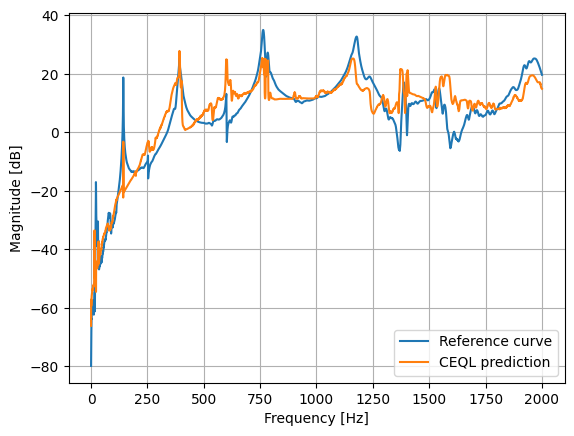

In [7]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path

# ------------------------------------------------------------
# Pick ONE experiment (one file) and plot mag_db vs frequency:
#   - ground truth curve
#   - CEQL prediction curve
# Then save as PDF into figures/
# ------------------------------------------------------------
rng = np.random.RandomState(SEED)
exp_id, cond, sample, fp = experiments[rng.randint(len(experiments))]

title_info = f"{exp_id} sample:{sample}"
print("Plotting:", title_info)

# Load curve
f, mag_db, ph_deg = read_frf_txt(fp)

# Build X for this curve using the SAME feature selection
X_curve, y_curve = build_feature_matrix(
    f=f,
    mag_db=mag_db,
    ph_deg=ph_deg,
    cond=cond,
    sample=sample,
    feature_tokens=FEATURE_TOKENS,
)

# Predict
model.eval()
with torch.no_grad():
    Xc = torch.from_numpy(X_curve).float().to(device)
    pred = model(Xc)

    pred_np = pred.detach().cpu().numpy()
    if np.iscomplexobj(pred_np):
        pred_np = pred_np.real
    pred_np = pred_np.reshape(-1)

y_np = y_curve.reshape(-1)

# Plot + save
order = np.argsort(f)
fig = plt.figure()
plt.plot(f[order], y_np[order], label="Reference curve")
plt.plot(f[order], pred_np[order], label="CEQL prediction")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Magnitude [dB]")
plt.legend()
plt.grid(True)

out_dir = Path("figures")
out_dir.mkdir(parents=True, exist_ok=True)

out_path = out_dir / f"frf_prediction.pdf"

fig.savefig(out_path, bbox_inches="tight")
print("Saved to:", out_path.as_posix())

plt.show()
